# Scenario Diagram Visualizations

Notebook ini membuat visualisasi yang direkomendasikan dalam `reports/week4/SCENARIO_DIAGRAM_ANALYSIS.md` hanya dari artefak CSV yang sudah ada. Tidak ada eksperimen embedding atau clustering yang dijalankan ulang.

Output baru disimpan ke `reports/week4/plots/scenario_analysis/`. Visualisasi yang sumber datanya tidak memadai akan dicatat sebagai `skipped`.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    from IPython.display import Markdown, display
except ImportError:
    class Markdown(str):
        pass
    def display(value):
        print(value)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
WEEK3 = PROJECT_ROOT / "reports" / "week3"
WEEK4 = PROJECT_ROOT / "reports" / "week4"
OUTPUT_DIR = WEEK4 / "plots" / "scenario_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REP_ORDER = ["tfidf", "word2vec", "doc2vec", "sbert"]
REP_LABEL = {"tfidf": "TF-IDF", "word2vec": "Word2Vec", "doc2vec": "Doc2Vec", "sbert": "SBERT"}
METHOD_ORDER = ["kmeans", "dbscan", "hdbscan", "agglomerative", "gmm"]
METHOD_LABEL = {"kmeans": "K-Means", "dbscan": "DBSCAN", "hdbscan": "HDBSCAN", "agglomerative": "Agglom.", "gmm": "GMM"}
COLORS = {"tfidf": "#377eb8", "word2vec": "#4daf4a", "doc2vec": "#984ea3", "sbert": "#ff7f00"}
plot_status = []

def load_csv(path):
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)

def save_plot(fig, filename, description):
    path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    plot_status.append({"visualization": description, "status": "created", "output_path": str(path.relative_to(PROJECT_ROOT)), "note": ""})

def skip_plot(description, note):
    plot_status.append({"visualization": description, "status": "skipped", "output_path": "", "note": note})
    display(Markdown(f"**Skipped:** {description} — {note}"))

def minmax(series, higher_is_better=True):
    values = pd.to_numeric(series, errors="coerce")
    low, high = values.min(), values.max()
    if pd.isna(low) or pd.isna(high) or math.isclose(float(low), float(high)):
        result = pd.Series(1.0, index=series.index)
    else:
        result = (values - low) / (high - low)
    return result if higher_is_better else 1.0 - result

primary = load_csv(WEEK4 / "metrics_primary_summary.csv")
primary_runs = load_csv(WEEK4 / "metrics_primary_runs.csv")
k_summary = load_csv(WEEK4 / "metrics_k_sensitivity_summary.csv")
k_by_value = load_csv(WEEK4 / "k_sensitivity_by_k_week4.csv")
k_diagnostics = load_csv(WEEK4 / "k_optimal_diagnostics_week4.csv")
cross_dataset = load_csv(WEEK4 / "cross_dataset_comparison.csv")
viz_times = load_csv(WEEK3 / "visualization_times_week3.csv")
interpretability = load_csv(WEEK4 / "manual_interpretability_review_week4.csv")
cd_results = load_csv(WEEK4 / "cd_friedman_nemenyi_week4.csv")

display(pd.Series({
    "primary_summary_rows": len(primary),
    "primary_run_rows": len(primary_runs),
    "k_summary_rows": len(k_summary),
    "k_by_value_rows": len(k_by_value),
    "cross_dataset_rows": len(cross_dataset),
    "interpretability_rows": len(interpretability),
}, name="loaded_rows"))

primary_summary_rows      20
primary_run_rows         100
k_summary_rows            10
k_by_value_rows           84
cross_dataset_rows         1
interpretability_rows     19
Name: loaded_rows, dtype: int64

## Skenario 1 — Kualitas Clustering

Tiga panel memakai mean dan standard deviation dari lima seed. Skala log digunakan untuk Calinski-Harabasz karena rentangnya sangat lebar.

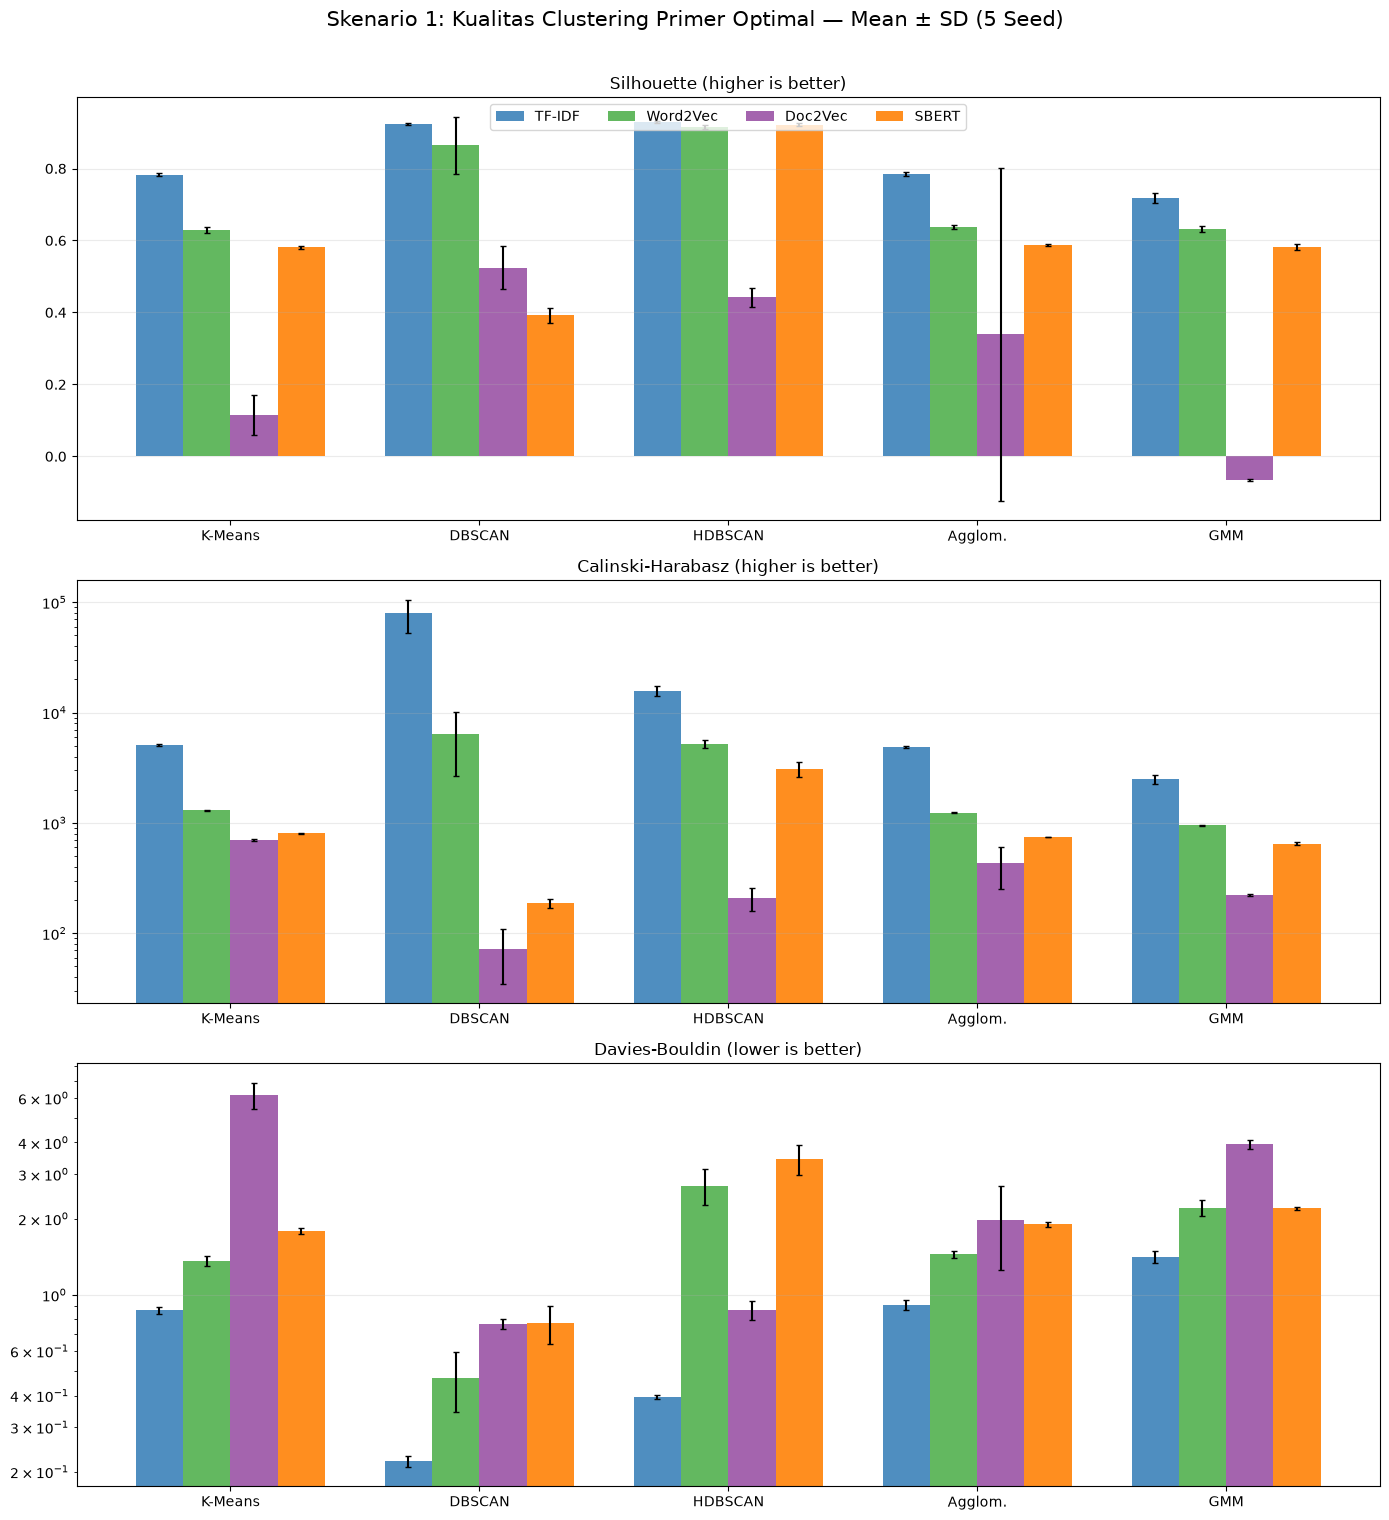

In [2]:
required = {"representation", "clustering_method", "silhouette_mean", "silhouette_std", "calinski_harabasz_mean", "calinski_harabasz_std", "davies_bouldin_mean", "davies_bouldin_std"}
if primary.empty or not required.issubset(primary.columns):
    skip_plot("Skenario 1 - kualitas clustering", "Kolom mean/std kualitas tidak lengkap.")
else:
    metrics = [
        ("silhouette_mean", "silhouette_std", "Silhouette (higher is better)", False),
        ("calinski_harabasz_mean", "calinski_harabasz_std", "Calinski-Harabasz (higher is better)", True),
        ("davies_bouldin_mean", "davies_bouldin_std", "Davies-Bouldin (lower is better)", True),
    ]
    fig, axes = plt.subplots(3, 1, figsize=(14, 15))
    x = np.arange(len(METHOD_ORDER))
    width = 0.19
    for ax, (mean_col, std_col, title, use_log) in zip(axes, metrics):
        for idx, rep in enumerate(REP_ORDER):
            rows = primary[primary["representation"].eq(rep)].set_index("clustering_method").reindex(METHOD_ORDER)
            ax.bar(x + (idx - 1.5) * width, rows[mean_col], width, yerr=rows[std_col], capsize=2.5, label=REP_LABEL[rep], color=COLORS[rep], alpha=0.88)
        ax.set_xticks(x)
        ax.set_xticklabels([METHOD_LABEL[m] for m in METHOD_ORDER])
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.25)
        if use_log and (primary[mean_col] > 0).all():
            ax.set_yscale("log")
    axes[0].legend(ncol=4, loc="upper center")
    fig.suptitle("Skenario 1: Kualitas Clustering Primer Optimal — Mean ± SD (5 Seed)", y=1.01, fontsize=15)
    save_plot(fig, "scenario_1_clustering_quality.png", "Skenario 1 - kualitas clustering")

## Skenario 2 — Performa Komputasi

Embedding time dan peak memory diringkas per representasi. Clustering time ditampilkan per kombinasi. Scatter-render time dihitung dari lima metode clustering pada setiap pasangan representasi dan metode visualisasi.

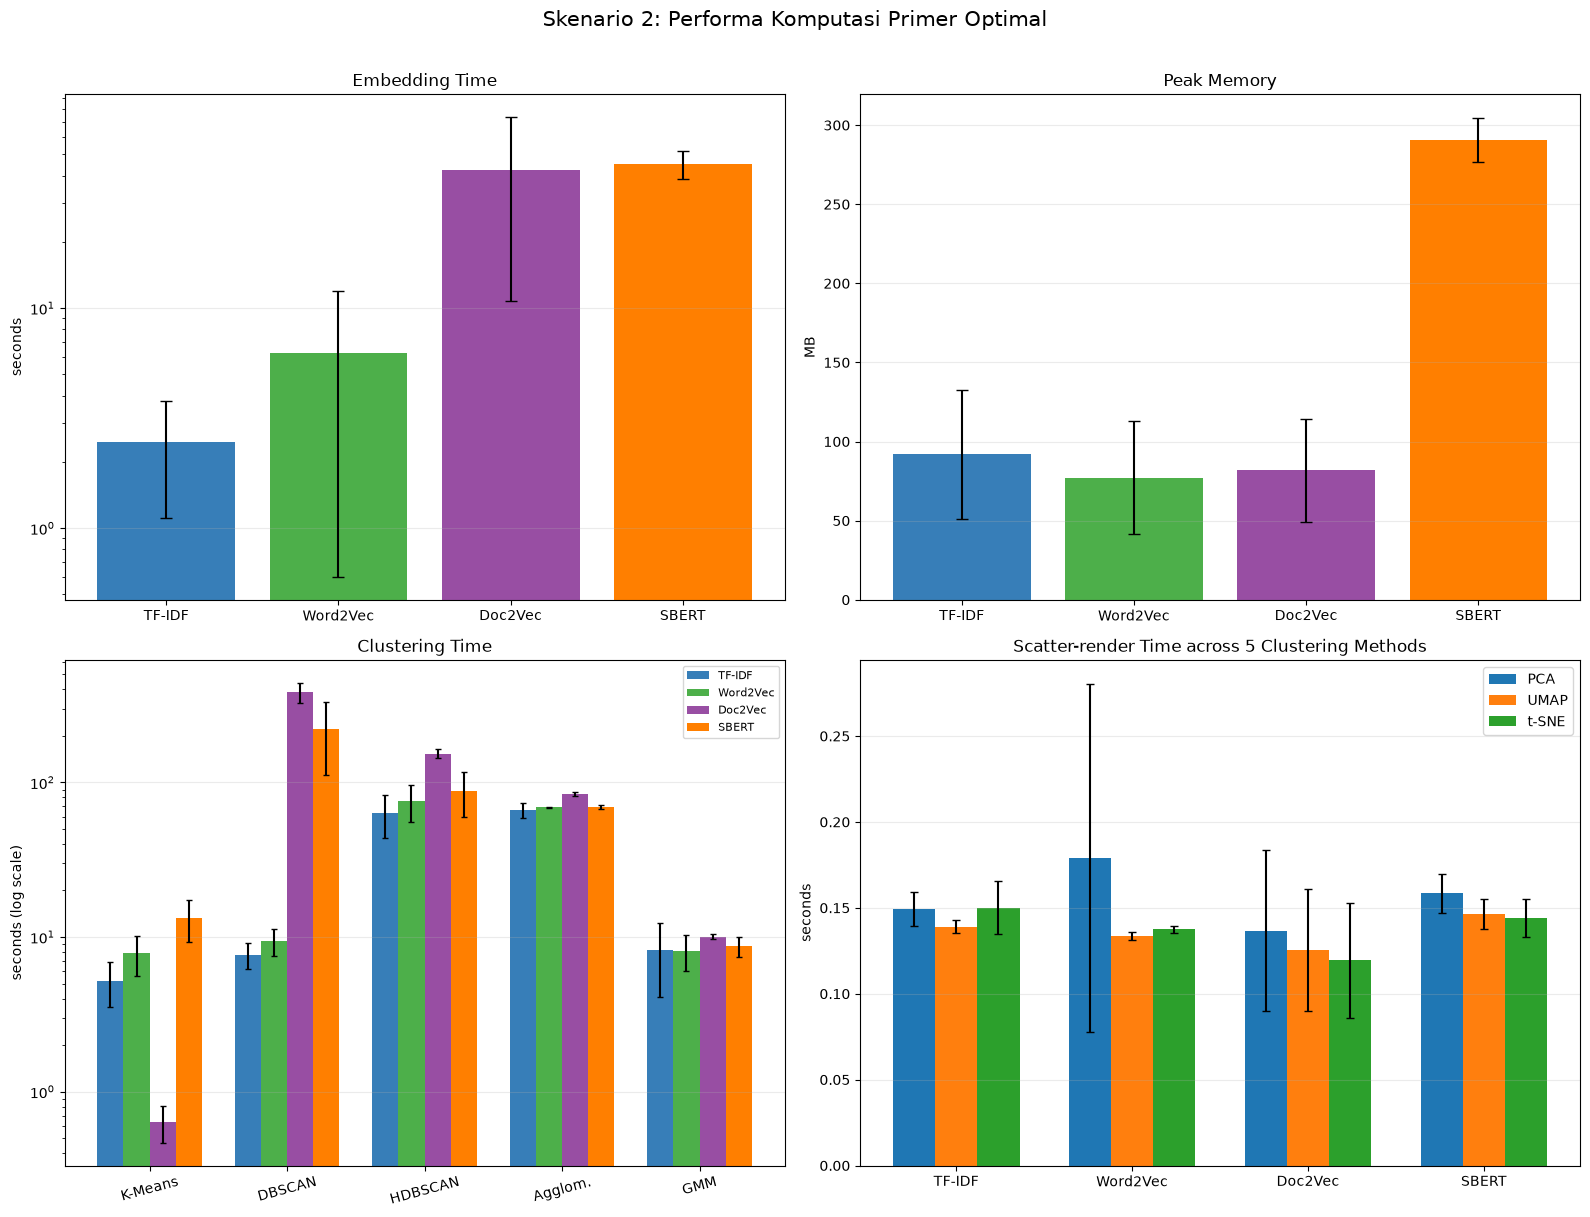

In [3]:
perf_required = {"representation", "clustering_method", "embedding_time_s_mean", "embedding_time_s_std", "peak_memory_mb_mean", "peak_memory_mb_std", "clustering_time_s_mean", "clustering_time_s_std"}
if primary.empty or not perf_required.issubset(primary.columns):
    skip_plot("Skenario 2 - performa komputasi", "Kolom performa primer tidak lengkap.")
else:
    rep_perf = primary.groupby("representation", as_index=True).agg(
        embedding_mean=("embedding_time_s_mean", "mean"), embedding_std=("embedding_time_s_std", "mean"),
        memory_mean=("peak_memory_mb_mean", "mean"), memory_std=("peak_memory_mb_std", "mean"),
    ).reindex(REP_ORDER)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0, 0].bar([REP_LABEL[r] for r in REP_ORDER], rep_perf["embedding_mean"], yerr=rep_perf["embedding_std"], capsize=4, color=[COLORS[r] for r in REP_ORDER])
    axes[0, 0].set_title("Embedding Time")
    axes[0, 0].set_ylabel("seconds")
    axes[0, 0].set_yscale("log")
    axes[0, 1].bar([REP_LABEL[r] for r in REP_ORDER], rep_perf["memory_mean"], yerr=rep_perf["memory_std"], capsize=4, color=[COLORS[r] for r in REP_ORDER])
    axes[0, 1].set_title("Peak Memory")
    axes[0, 1].set_ylabel("MB")
    x = np.arange(len(METHOD_ORDER)); width = 0.19
    for idx, rep in enumerate(REP_ORDER):
        rows = primary[primary["representation"].eq(rep)].set_index("clustering_method").reindex(METHOD_ORDER)
        axes[1, 0].bar(x + (idx - 1.5) * width, rows["clustering_time_s_mean"], width, yerr=rows["clustering_time_s_std"], capsize=2, label=REP_LABEL[rep], color=COLORS[rep])
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels([METHOD_LABEL[m] for m in METHOD_ORDER], rotation=15)
    axes[1, 0].set_title("Clustering Time")
    axes[1, 0].set_ylabel("seconds (log scale)")
    axes[1, 0].set_yscale("log")
    axes[1, 0].legend(fontsize=8)
    render = viz_times[(viz_times.get("stage") == "scatter_render") & (viz_times.get("status") == "ok")].copy() if not viz_times.empty else pd.DataFrame()
    if render.empty:
        axes[1, 1].text(0.5, 0.5, "Scatter-render timing unavailable", ha="center", va="center")
        axes[1, 1].set_axis_off()
    else:
        render_summary = render.groupby(["representation", "visualization_method"])["elapsed_s"].agg(["mean", "std"]).reset_index()
        methods = ["pca", "umap", "tsne"]
        x2 = np.arange(len(REP_ORDER)); width2 = 0.24
        for idx, method in enumerate(methods):
            rows = render_summary[render_summary["visualization_method"].eq(method)].set_index("representation").reindex(REP_ORDER)
            axes[1, 1].bar(x2 + (idx - 1) * width2, rows["mean"], width2, yerr=rows["std"].fillna(0), capsize=3, label=method.upper().replace("TSNE", "t-SNE"))
        axes[1, 1].set_xticks(x2)
        axes[1, 1].set_xticklabels([REP_LABEL[r] for r in REP_ORDER])
        axes[1, 1].set_title("Scatter-render Time across 5 Clustering Methods")
        axes[1, 1].set_ylabel("seconds")
        axes[1, 1].legend()
    for ax in axes.flat:
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle("Skenario 2: Performa Komputasi Primer Optimal", y=1.01, fontsize=15)
    save_plot(fig, "scenario_2_computational_performance.png", "Skenario 2 - performa komputasi")

## Skenario 3 — Jumlah Cluster dan Noise Ratio

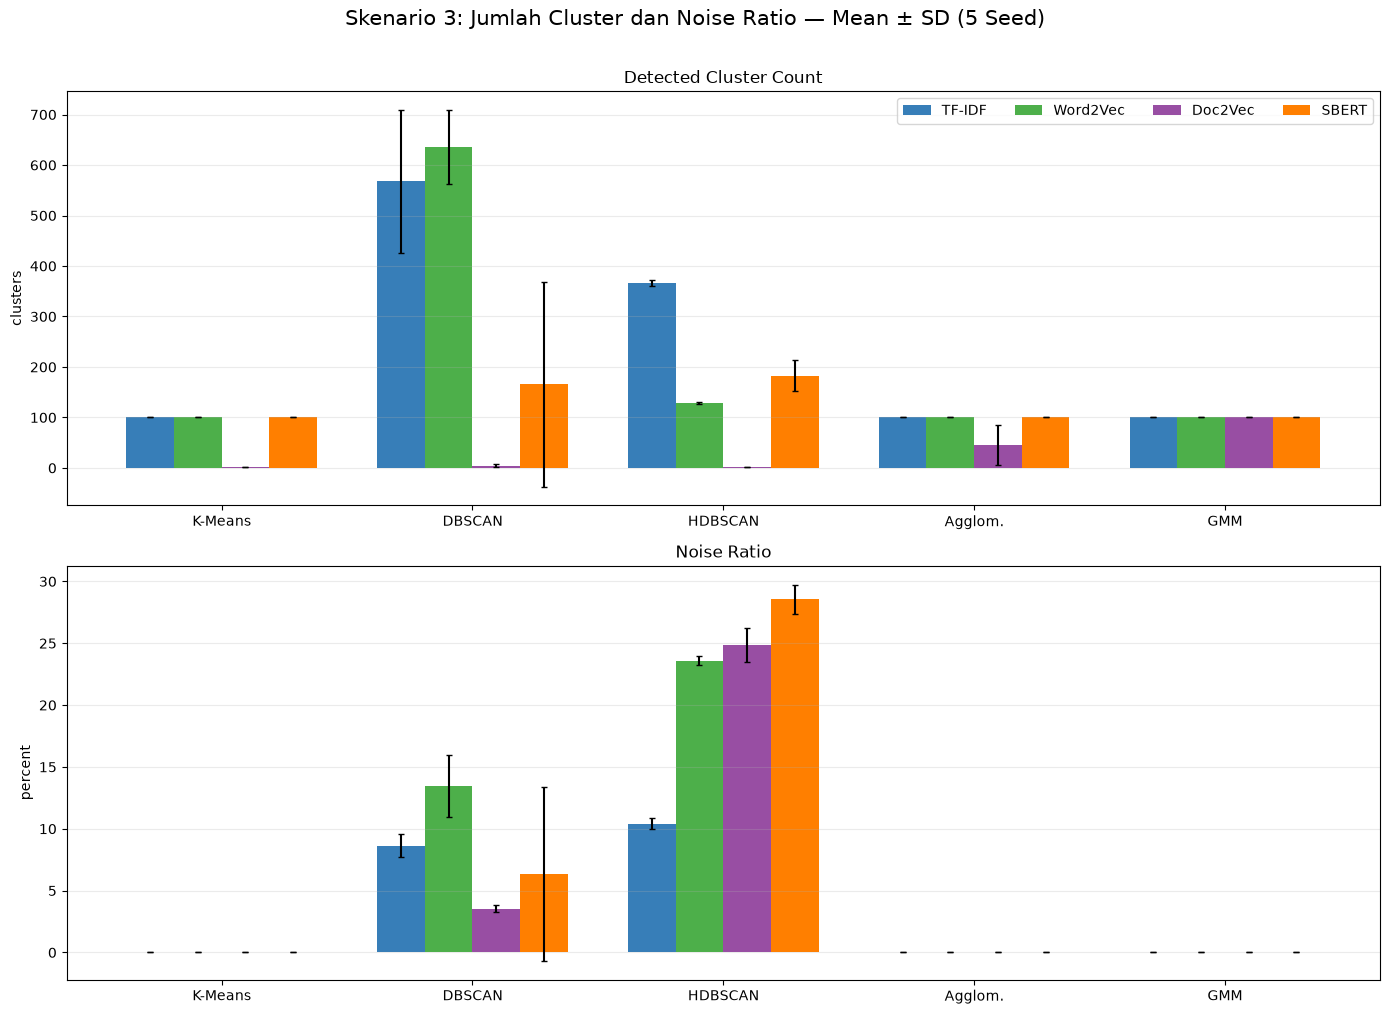

In [4]:
cluster_required = {"representation", "clustering_method", "n_clusters_mean", "n_clusters_std", "noise_ratio_mean", "noise_ratio_std"}
if primary.empty or not cluster_required.issubset(primary.columns):
    skip_plot("Skenario 3 - jumlah cluster dan noise ratio", "Kolom cluster/noise tidak lengkap.")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    x = np.arange(len(METHOD_ORDER)); width = 0.19
    for idx, rep in enumerate(REP_ORDER):
        rows = primary[primary["representation"].eq(rep)].set_index("clustering_method").reindex(METHOD_ORDER)
        pos = x + (idx - 1.5) * width
        axes[0].bar(pos, rows["n_clusters_mean"], width, yerr=rows["n_clusters_std"], capsize=2, label=REP_LABEL[rep], color=COLORS[rep])
        axes[1].bar(pos, rows["noise_ratio_mean"] * 100, width, yerr=rows["noise_ratio_std"] * 100, capsize=2, color=COLORS[rep])
    axes[0].set_title("Detected Cluster Count")
    axes[0].set_ylabel("clusters")
    axes[0].legend(ncol=4)
    axes[1].set_title("Noise Ratio")
    axes[1].set_ylabel("percent")
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels([METHOD_LABEL[m] for m in METHOD_ORDER])
        ax.grid(axis="y", alpha=0.25)
    fig.suptitle("Skenario 3: Jumlah Cluster dan Noise Ratio — Mean ± SD (5 Seed)", y=1.01, fontsize=15)
    save_plot(fig, "scenario_3_clusters_and_noise.png", "Skenario 3 - jumlah cluster dan noise ratio")

## Skenario 4 — Ringkasan K-Sensitivity

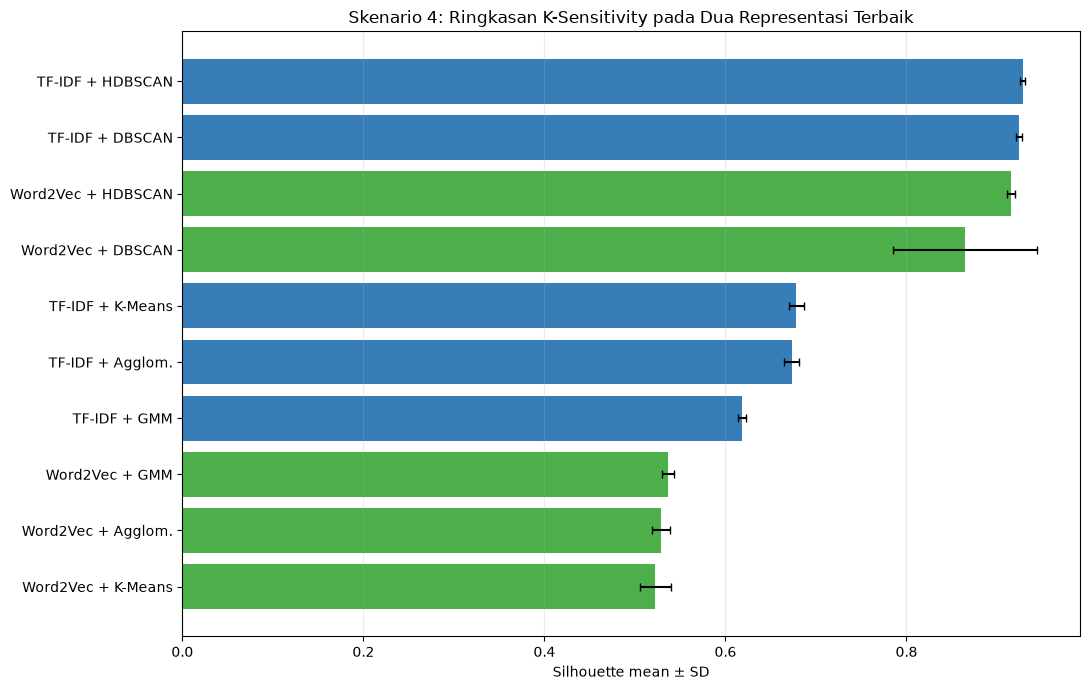

In [5]:
if k_summary.empty or not {"representation", "clustering_method", "silhouette_mean", "silhouette_std"}.issubset(k_summary.columns):
    skip_plot("Skenario 4 - ringkasan K-sensitivity", "Summary K-sensitivity tidak tersedia.")
else:
    frame = k_summary.copy()
    frame["combo"] = frame["representation"].map(REP_LABEL).fillna(frame["representation"]) + " + " + frame["clustering_method"].map(METHOD_LABEL).fillna(frame["clustering_method"])
    frame = frame.sort_values("silhouette_mean")
    fig, ax = plt.subplots(figsize=(11, 7))
    colors = frame["representation"].map(COLORS).fillna("#777777")
    ax.barh(frame["combo"], frame["silhouette_mean"], xerr=frame["silhouette_std"], capsize=3, color=colors)
    ax.set_xlabel("Silhouette mean ± SD")
    ax.set_title("Skenario 4: Ringkasan K-Sensitivity pada Dua Representasi Terbaik")
    ax.grid(axis="x", alpha=0.25)
    save_plot(fig, "scenario_4_k_sensitivity_summary.png", "Skenario 4 - ringkasan K-sensitivity")

## Skenario 5 — K-Sensitivity Eksplisit

Panel utama hanya memakai parameter `k` atau `n_components`. Density parameters DBSCAN/HDBSCAN tidak dipaksakan ke sumbu K.

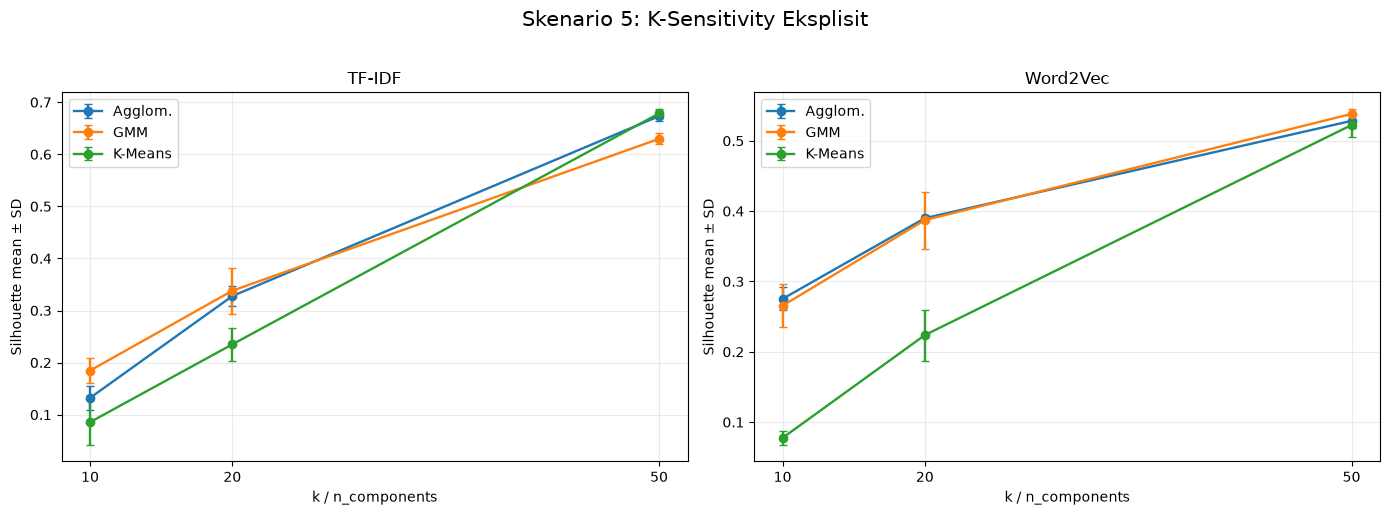

In [6]:
explicit = k_by_value[k_by_value.get("parameter_type", pd.Series(dtype=str)).isin(["k", "n_components"])].copy() if not k_by_value.empty else pd.DataFrame()
if explicit.empty:
    skip_plot("Skenario 5 - K-sensitivity eksplisit", "Tidak ada baris parameter k/n_components.")
else:
    reps = [r for r in ["tfidf", "word2vec"] if r in explicit["representation"].unique()]
    fig, axes = plt.subplots(1, len(reps), figsize=(7 * len(reps), 5), squeeze=False)
    for ax, rep in zip(axes[0], reps):
        rep_df = explicit[explicit["representation"].eq(rep)].copy()
        rep_df["parameter_value"] = pd.to_numeric(rep_df["parameter_value"], errors="coerce")
        for method, group in rep_df.groupby("clustering_method"):
            group = group.sort_values("parameter_value")
            ax.errorbar(group["parameter_value"], group["silhouette_mean"], yerr=group["silhouette_std"], marker="o", capsize=3, linewidth=1.7, label=METHOD_LABEL.get(method, method))
        ax.set_title(REP_LABEL.get(rep, rep))
        ax.set_xlabel("k / n_components")
        ax.set_ylabel("Silhouette mean ± SD")
        ax.set_xticks([10, 20, 50])
        ax.grid(alpha=0.25)
        ax.legend()
    fig.suptitle("Skenario 5: K-Sensitivity Eksplisit", y=1.02, fontsize=15)
    save_plot(fig, "scenario_5_explicit_k_sensitivity.png", "Skenario 5 - K-sensitivity eksplisit")

## Skenario 6 — Cross-Dataset Validation

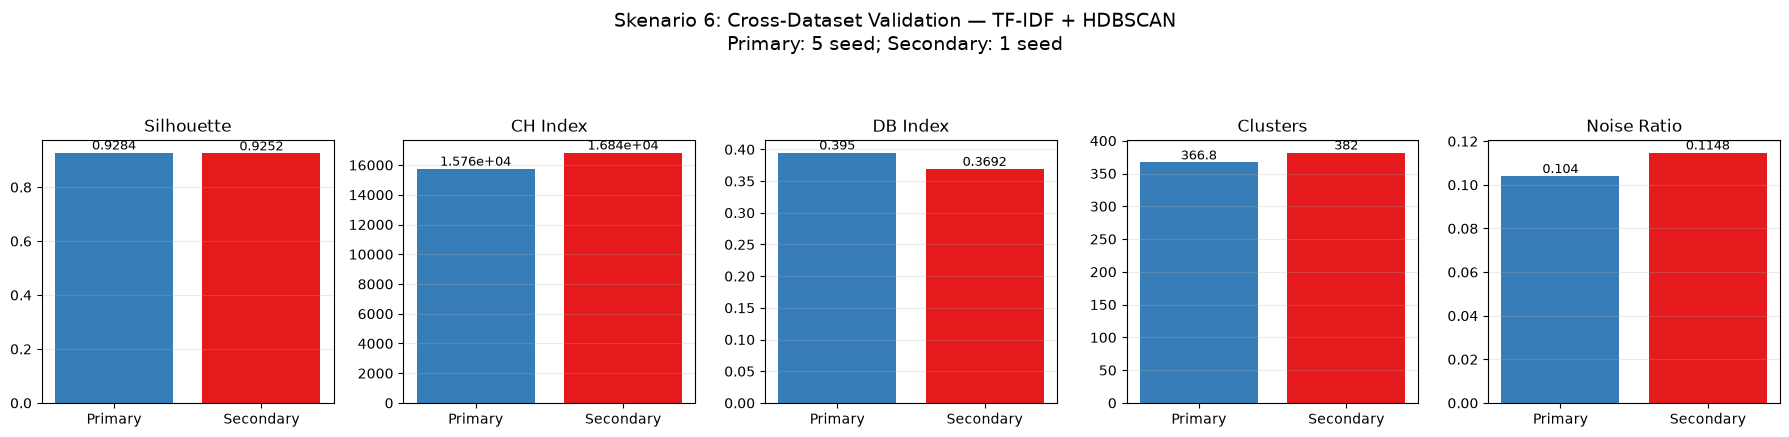

In [7]:
cross_metrics = [
    ("Silhouette", "primary_silhouette_mean", "secondary_silhouette_mean"),
    ("CH Index", "primary_calinski_harabasz_mean", "secondary_calinski_harabasz_mean"),
    ("DB Index", "primary_davies_bouldin_mean", "secondary_davies_bouldin_mean"),
    ("Clusters", "primary_n_clusters_mean", "secondary_n_clusters_mean"),
    ("Noise Ratio", "primary_noise_ratio_mean", "secondary_noise_ratio_mean"),
]
needed = {column for _, p, s in cross_metrics for column in (p, s)}
if cross_dataset.empty or not needed.issubset(cross_dataset.columns):
    skip_plot("Skenario 6 - cross-dataset validation", "Kolom perbandingan dataset tidak lengkap.")
else:
    row = cross_dataset.iloc[0]
    fig, axes = plt.subplots(1, len(cross_metrics), figsize=(18, 4))
    for ax, (label, primary_col, secondary_col) in zip(axes, cross_metrics):
        values = [row[primary_col], row[secondary_col]]
        ax.bar(["Primary", "Secondary"], values, color=["#377eb8", "#e41a1c"])
        ax.set_title(label)
        ax.grid(axis="y", alpha=0.25)
        for idx, value in enumerate(values):
            ax.text(idx, value, f"{value:.4g}", ha="center", va="bottom", fontsize=9)
    fig.suptitle("Skenario 6: Cross-Dataset Validation — TF-IDF + HDBSCAN\nPrimary: 5 seed; Secondary: 1 seed", y=1.08, fontsize=14)
    save_plot(fig, "scenario_6_cross_dataset_validation.png", "Skenario 6 - cross-dataset validation")

## Skenario 7 — Waktu Reduksi PCA/UMAP/t-SNE

Hanya baris `stage=reduction` yang digunakan. Data ini merupakan satu pengukuran per pasangan, sehingga tidak diberi error bar.

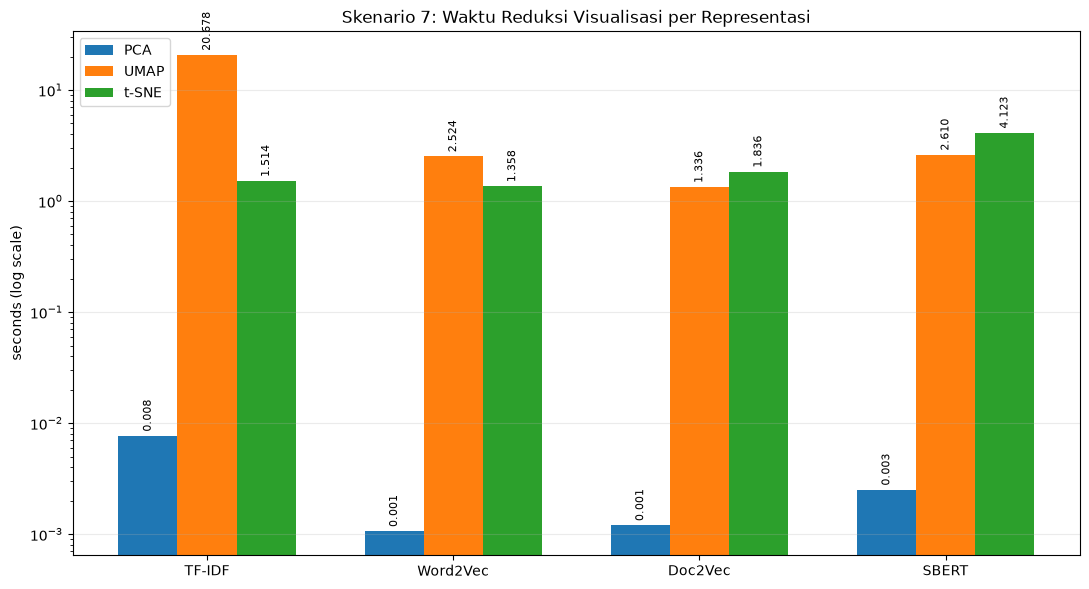

In [8]:
reduction = viz_times[(viz_times.get("stage") == "reduction") & (viz_times.get("status") == "ok")].copy() if not viz_times.empty else pd.DataFrame()
if reduction.empty:
    skip_plot("Skenario 7 - waktu reduksi visualisasi", "Baris stage=reduction tidak tersedia.")
else:
    pivot = reduction.pivot_table(index="representation", columns="visualization_method", values="elapsed_s", aggfunc="sum").reindex(REP_ORDER)
    methods = [m for m in ["pca", "umap", "tsne"] if m in pivot.columns]
    fig, ax = plt.subplots(figsize=(11, 6))
    x = np.arange(len(REP_ORDER)); width = 0.24
    for idx, method in enumerate(methods):
        bars = ax.bar(x + (idx - 1) * width, pivot[method], width, label=method.upper().replace("TSNE", "t-SNE"))
        ax.bar_label(bars, fmt="%.3f", fontsize=8, rotation=90, padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels([REP_LABEL[r] for r in REP_ORDER])
    ax.set_ylabel("seconds (log scale)")
    ax.set_yscale("log")
    ax.set_title("Skenario 7: Waktu Reduksi Visualisasi per Representasi")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    save_plot(fig, "scenario_7_reduction_time.png", "Skenario 7 - waktu reduksi visualisasi")

## Skenario 8 — Forensic Interpretability Proxy

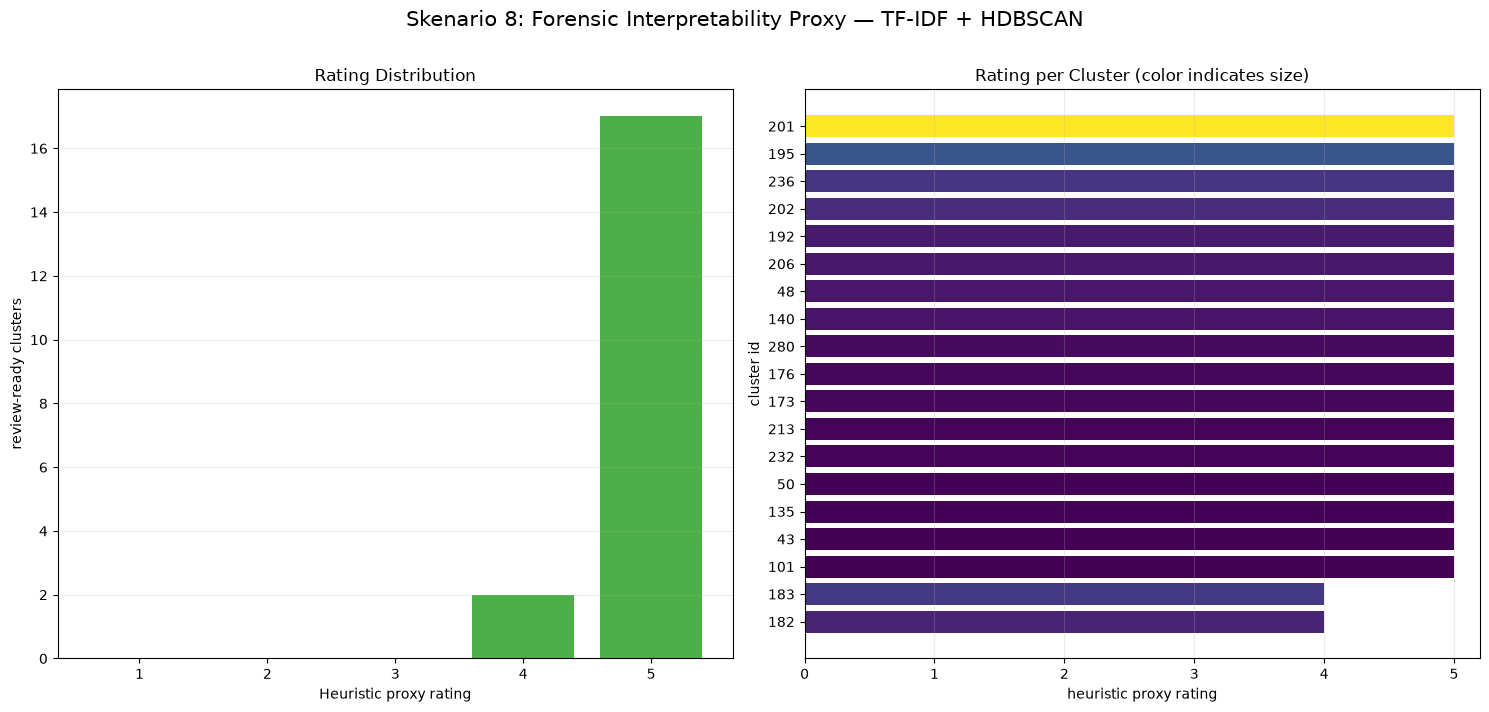

In [9]:
if interpretability.empty or not {"cluster_id", "size", "suggested_rating_1_5"}.issubset(interpretability.columns):
    skip_plot("Skenario 8 - forensic interpretability proxy", "Data review interpretability tidak lengkap.")
else:
    review = interpretability.copy()
    review["suggested_rating_1_5"] = pd.to_numeric(review["suggested_rating_1_5"], errors="coerce")
    distribution = review["suggested_rating_1_5"].value_counts().reindex(range(1, 6), fill_value=0)
    ranked = review.sort_values(["suggested_rating_1_5", "size"], ascending=[True, True])
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    axes[0].bar(distribution.index.astype(str), distribution.values, color="#4daf4a")
    axes[0].set_xlabel("Heuristic proxy rating")
    axes[0].set_ylabel("review-ready clusters")
    axes[0].set_title("Rating Distribution")
    axes[0].grid(axis="y", alpha=0.25)
    colors = plt.cm.viridis((ranked["size"] - ranked["size"].min()) / max(1, ranked["size"].max() - ranked["size"].min()))
    axes[1].barh(ranked["cluster_id"].astype(str), ranked["suggested_rating_1_5"], color=colors)
    axes[1].set_xlim(0, 5.2)
    axes[1].set_xlabel("heuristic proxy rating")
    axes[1].set_ylabel("cluster id")
    axes[1].set_title("Rating per Cluster (color indicates size)")
    axes[1].grid(axis="x", alpha=0.25)
    fig.suptitle("Skenario 8: Forensic Interpretability Proxy — TF-IDF + HDBSCAN", y=1.01, fontsize=15)
    save_plot(fig, "scenario_8_interpretability_proxy.png", "Skenario 8 - forensic interpretability proxy")

## Mini Project — K-Optimal Diagnostics

Silhouette tersedia untuk K-Means, Agglomerative, dan GMM. Inertia hanya relevan untuk K-Means, sedangkan BIC hanya relevan untuk GMM. Panel yang tidak memiliki data akan dilewati.

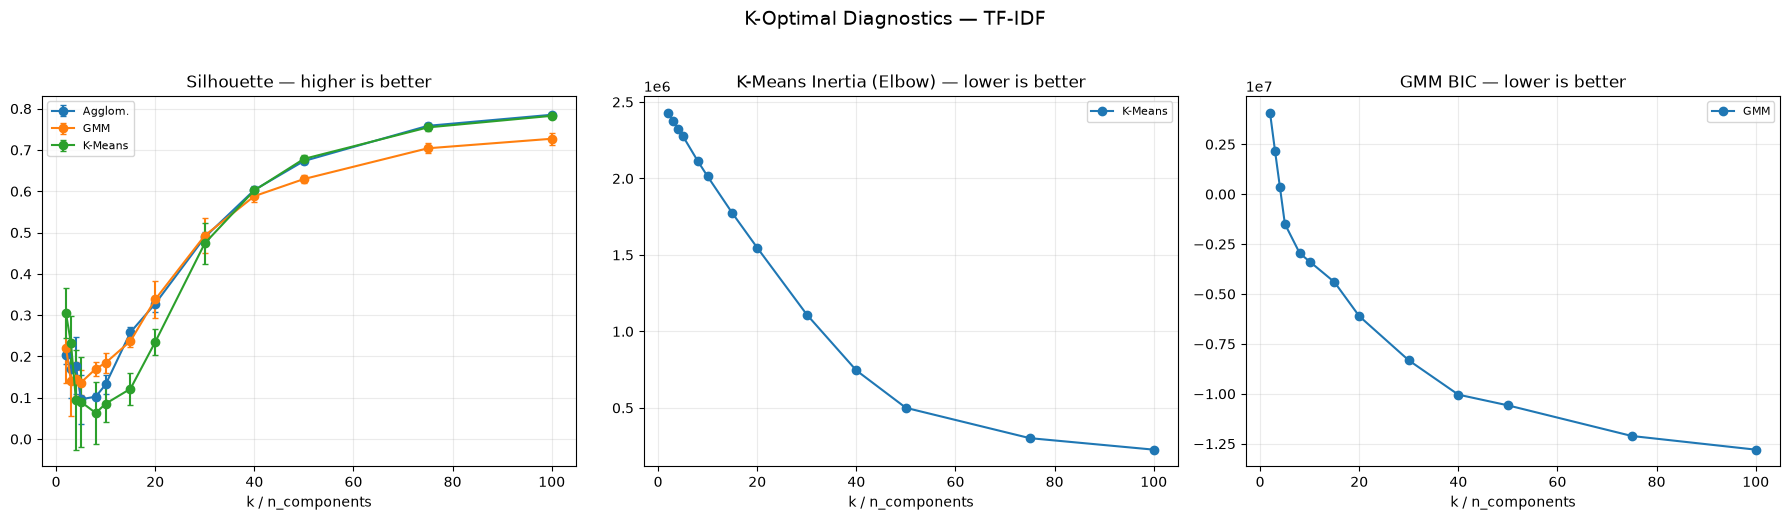

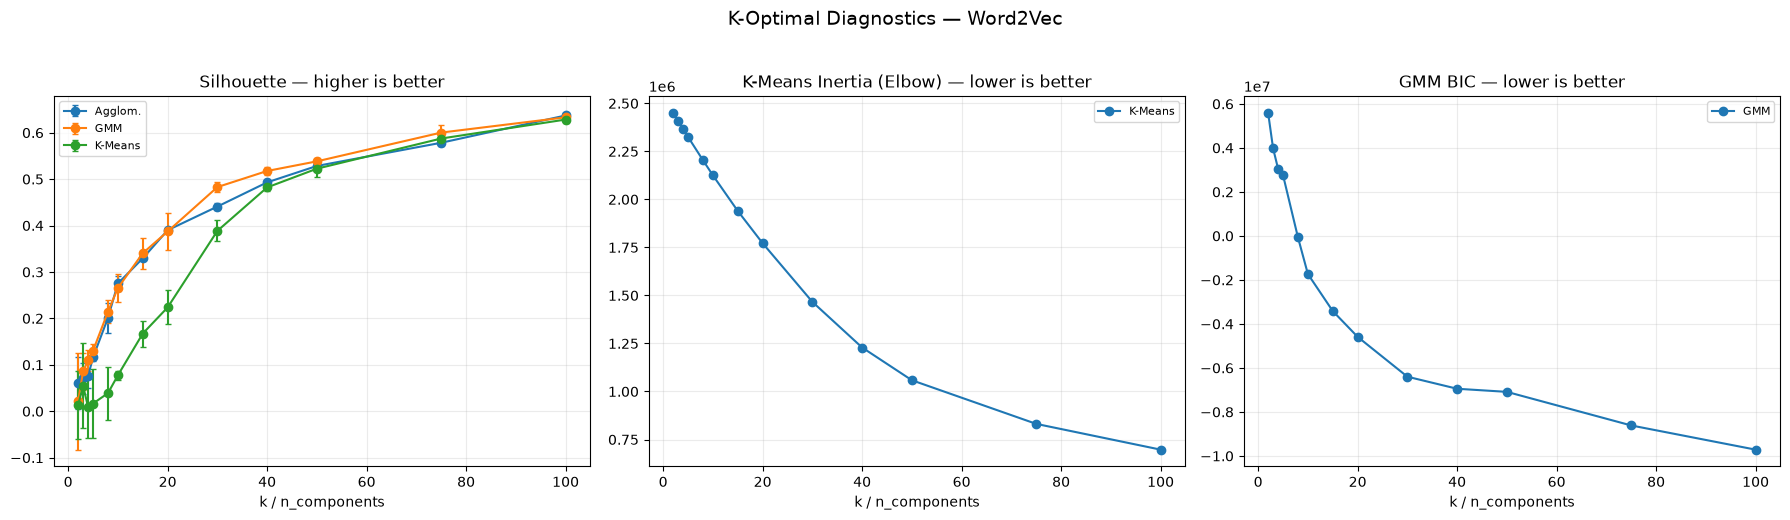

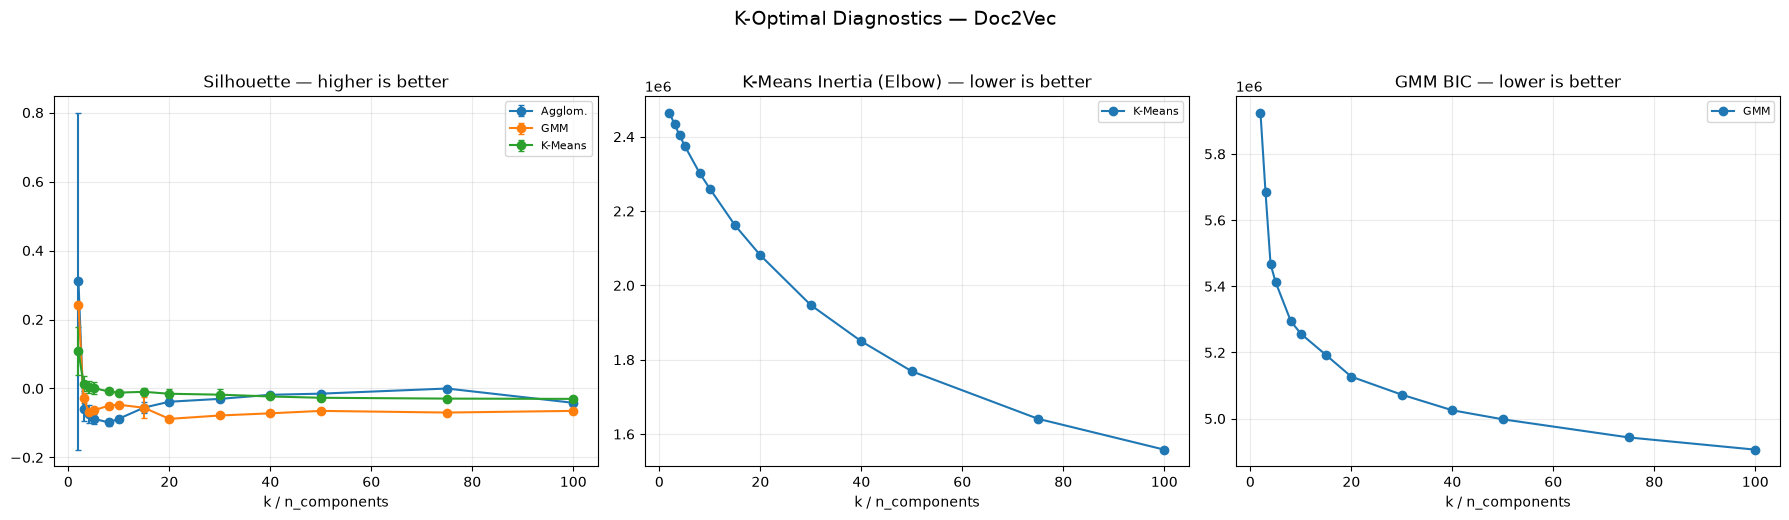

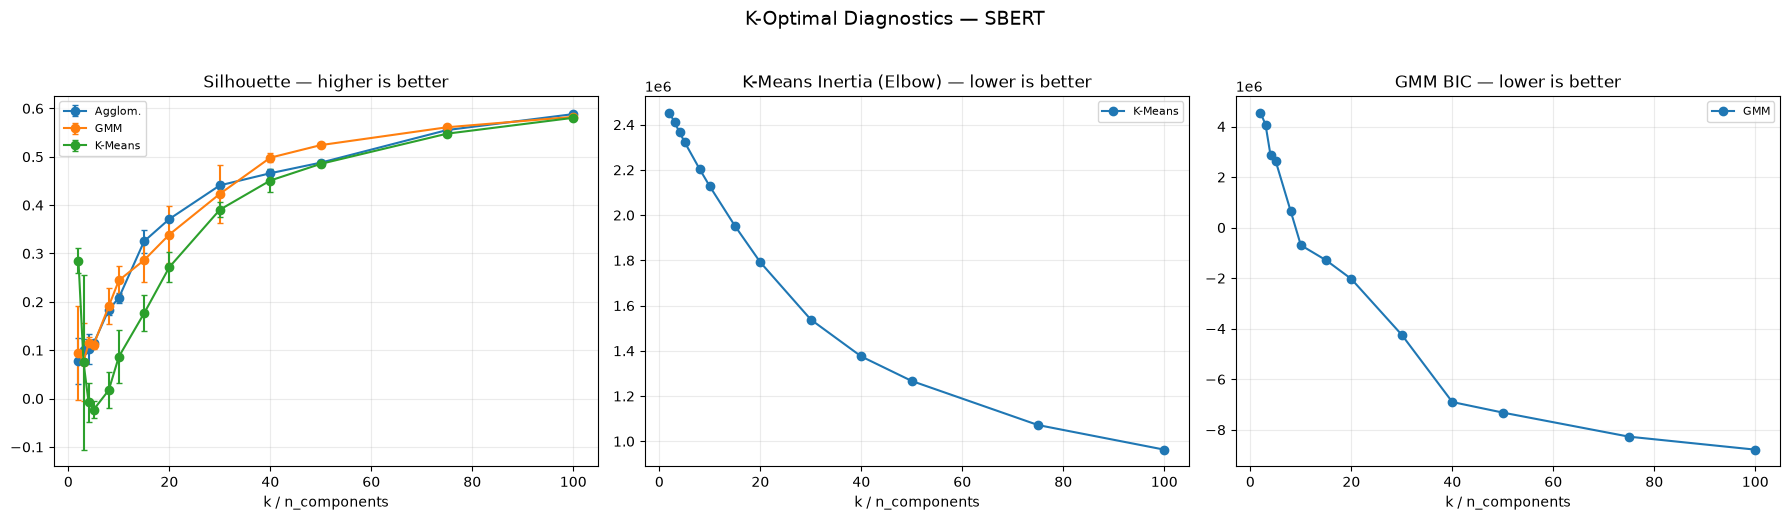

In [10]:
if k_diagnostics.empty:
    skip_plot("K-optimal diagnostics per representation", "k_optimal_diagnostics_week4.csv tidak tersedia.")
else:
    for rep in REP_ORDER:
        frame = k_diagnostics[k_diagnostics["representation"].eq(rep)].copy()
        if frame.empty:
            skip_plot(f"K-optimal diagnostics - {rep}", "Tidak ada baris untuk representasi ini.")
            continue
        available_panels = [("silhouette_mean", "Silhouette", False)]
        if frame.get("inertia_mean", pd.Series(dtype=float)).notna().any():
            available_panels.append(("inertia_mean", "K-Means Inertia (Elbow)", True))
        if frame.get("bic_mean", pd.Series(dtype=float)).notna().any():
            available_panels.append(("bic_mean", "GMM BIC", True))
        fig, axes = plt.subplots(1, len(available_panels), figsize=(6 * len(available_panels), 5), squeeze=False)
        for ax, (column, title, lower_better) in zip(axes[0], available_panels):
            for method, group in frame.dropna(subset=[column]).groupby("clustering_method"):
                group = group.sort_values("parameter_value_numeric")
                yerr = group["silhouette_std"] if column == "silhouette_mean" and "silhouette_std" in group else None
                ax.errorbar(group["parameter_value_numeric"], group[column], yerr=yerr, marker="o", capsize=2, label=METHOD_LABEL.get(method, method))
            ax.set_title(title + (" — lower is better" if lower_better else " — higher is better"))
            ax.set_xlabel("k / n_components")
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8)
        fig.suptitle(f"K-Optimal Diagnostics — {REP_LABEL[rep]}", y=1.03, fontsize=14)
        save_plot(fig, f"k_optimal_diagnostics_{rep}.png", f"K-optimal diagnostics - {rep}")

## Mini Project — Radar Multi-Metrik per Representasi

Radar ini menutup gap diagram existing yang membandingkan top-5 pipeline. Nilai berikut diagregasi per representasi dan dinormalisasi; DB Index serta waktu dibalik agar nilai lebih tinggi selalu berarti lebih baik.

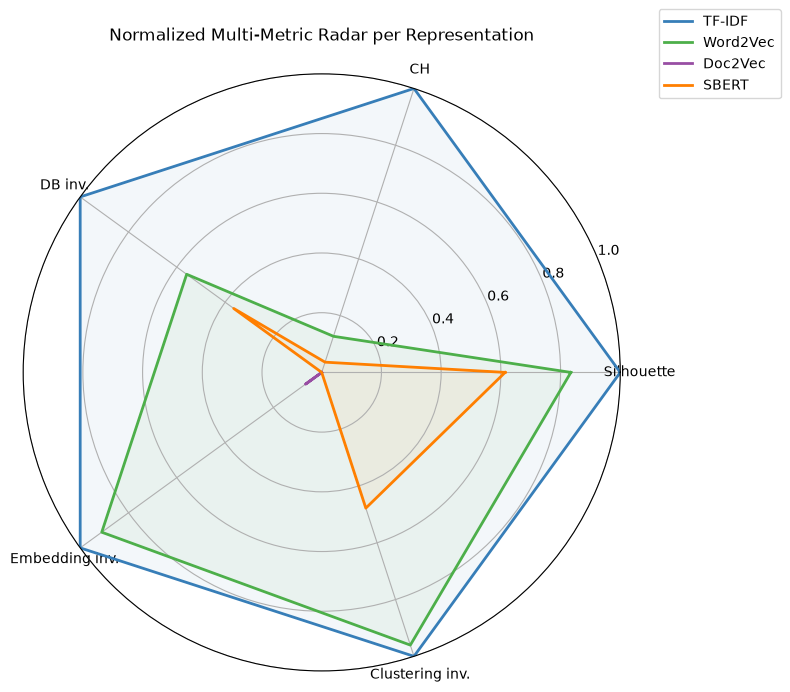

In [11]:
radar_required = {"representation", "silhouette_mean", "calinski_harabasz_mean", "davies_bouldin_mean", "embedding_time_s_mean", "clustering_time_s_mean"}
if primary.empty or not radar_required.issubset(primary.columns):
    skip_plot("Radar multi-metrik per representasi", "Kolom radar tidak lengkap.")
else:
    radar = primary.groupby("representation", as_index=False).agg(
        silhouette=("silhouette_mean", "mean"),
        ch=("calinski_harabasz_mean", "mean"),
        db=("davies_bouldin_mean", "mean"),
        embedding_time=("embedding_time_s_mean", "mean"),
        clustering_time=("clustering_time_s_mean", "mean"),
    ).set_index("representation").reindex(REP_ORDER)
    normalized = pd.DataFrame(index=radar.index)
    normalized["Silhouette"] = minmax(radar["silhouette"], True)
    normalized["CH"] = minmax(radar["ch"], True)
    normalized["DB inv."] = minmax(radar["db"], False)
    normalized["Embedding inv."] = minmax(radar["embedding_time"], False)
    normalized["Clustering inv."] = minmax(radar["clustering_time"], False)
    labels = normalized.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist(); angles += angles[:1]
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
    for rep in REP_ORDER:
        values = normalized.loc[rep].tolist(); values += values[:1]
        ax.plot(angles, values, linewidth=2, label=REP_LABEL[rep], color=COLORS[rep])
        ax.fill(angles, values, alpha=0.06, color=COLORS[rep])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_title("Normalized Multi-Metric Radar per Representation", pad=24)
    ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))
    save_plot(fig, "radar_metrics_by_representation.png", "Radar multi-metrik per representasi")

## Mini Project — Friedman-Nemenyi Critical Difference Reference

Notebook merekonstruksi diagram dari tabel statistik existing. Ini adalah mean-rank plot dengan referensi critical difference, bukan pairwise Nemenyi clique diagram lengkap.

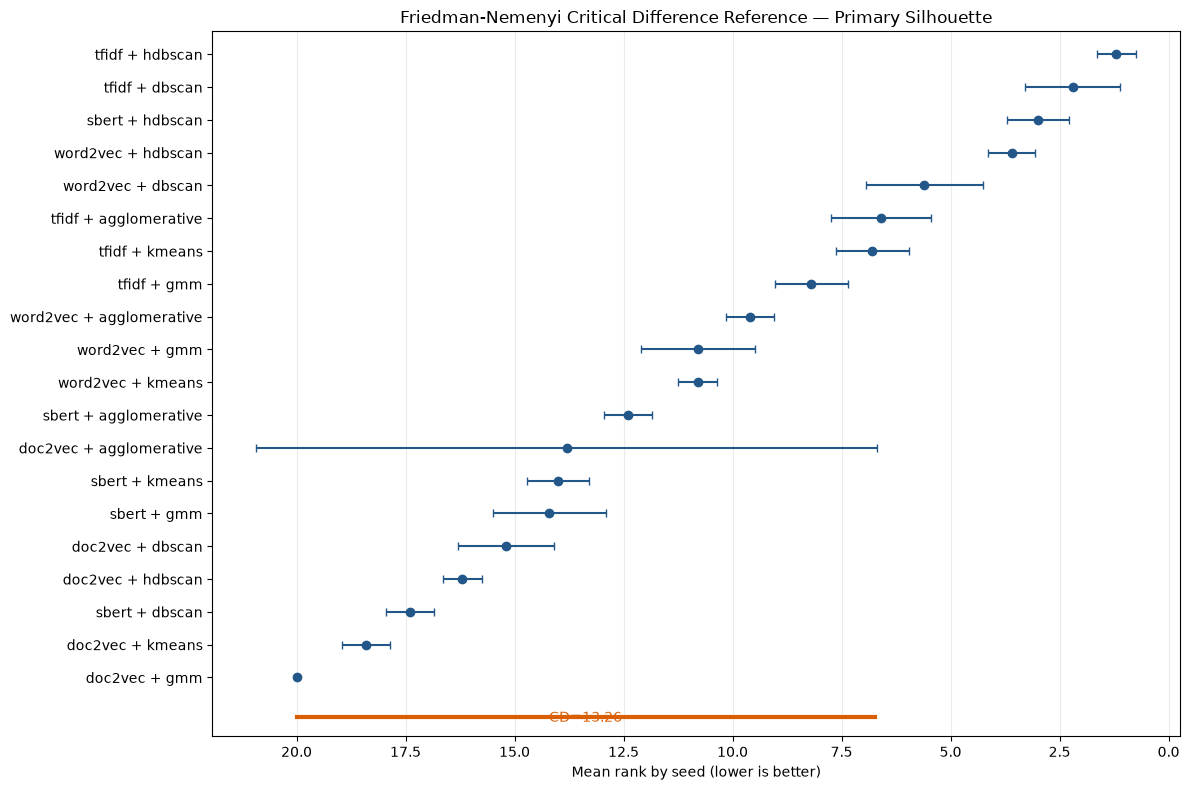

In [12]:
if cd_results.empty or not {"combo", "mean_rank", "rank_std", "nemenyi_critical_difference"}.issubset(cd_results.columns):
    skip_plot("Friedman-Nemenyi CD reference", "Tabel statistik tidak lengkap.")
else:
    frame = cd_results.sort_values("mean_rank").copy()
    fig, ax = plt.subplots(figsize=(12, 8))
    y = np.arange(len(frame))
    ax.errorbar(frame["mean_rank"], y, xerr=frame["rank_std"], fmt="o", color="#235789", capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(frame["combo"])
    ax.invert_yaxis(); ax.invert_xaxis()
    ax.set_xlabel("Mean rank by seed (lower is better)")
    ax.set_title("Friedman-Nemenyi Critical Difference Reference — Primary Silhouette")
    ax.grid(axis="x", alpha=0.25)
    cd = float(frame["nemenyi_critical_difference"].dropna().iloc[0]) if frame["nemenyi_critical_difference"].notna().any() else np.nan
    if np.isfinite(cd):
        xmax = float(frame["mean_rank"].max()); y_cd = len(frame) + 0.2
        ax.plot([xmax - cd, xmax], [y_cd, y_cd], color="#d95f02", linewidth=3)
        ax.text(xmax - cd / 2, y_cd + 0.15, f"CD={cd:.2f}", ha="center", color="#d95f02")
        ax.set_ylim(y_cd + 0.6, -0.7)
    save_plot(fig, "friedman_nemenyi_cd_reference.png", "Friedman-Nemenyi CD reference")

## Existing Visual Assets

Scatter grids, dendrograms, source distributions, timelines, Pareto front, dan word clouds sudah tersedia sebagai PNG. Notebook ini tidak meregenerasi visual tersebut karena sumber koordinat/label lengkap atau seluruh full word-cloud PNG tidak semuanya tracked.

In [13]:
existing_checks = {
    "PCA scatter grid": WEEK3 / "scatter_grids" / "pca_grid.png",
    "UMAP scatter grid": WEEK3 / "scatter_grids" / "umap_grid.png",
    "t-SNE scatter grid": WEEK3 / "scatter_grids" / "tsne_grid.png",
    "TF-IDF dendrogram": WEEK3 / "dendrograms" / "tfidf_agglomerative_dendrogram.png",
    "TF-IDF + HDBSCAN source distribution": WEEK3 / "source_distribution" / "tfidf_hdbscan_source.png",
    "TF-IDF + HDBSCAN timeline": WEEK3 / "timelines" / "tfidf_hdbscan_timeline.png",
    "Pareto front": WEEK4 / "plots" / "pareto_silhouette_runtime.png",
    "Aggregate word cloud": WEEK4 / "plots" / "wordclouds" / "tfidf_hdbscan_aggregate.png",
}
display(pd.DataFrame([{"asset": name, "exists": path.exists(), "path": str(path.relative_to(PROJECT_ROOT))} for name, path in existing_checks.items()]))
skip_plot("Full word cloud per all clusters", "Tracked repository contains 12 cluster PNGs plus one aggregate; full 367-cluster PNG set is not present.")

,asset,exists,path
0,PCA scatter grid,True,reports\week3\scatter_grids\pca_grid.png
1,UMAP scatter grid,True,reports\week3\scatter_grids\umap_grid.png
2,t-SNE scatter grid,True,reports\week3\scatter_grids\tsne_grid.png
3,TF-IDF dendrogram,True,reports\week3\dendrograms\tfidf_agglomerative_...
4,TF-IDF + HDBSCAN source distribution,True,reports\week3\source_distribution\tfidf_hdbsca...
5,TF-IDF + HDBSCAN timeline,True,reports\week3\timelines\tfidf_hdbscan_timeline...
6,Pareto front,True,reports\week4\plots\pareto_silhouette_runtime.png
7,Aggregate word cloud,True,reports\week4\plots\wordclouds\tfidf_hdbscan_a...


**Skipped:** Full word cloud per all clusters — Tracked repository contains 12 cluster PNGs plus one aggregate; full 367-cluster PNG set is not present.

## Output Manifest

In [14]:
manifest = pd.DataFrame(plot_status)
manifest_path = OUTPUT_DIR / "visualization_manifest.csv"
manifest.to_csv(manifest_path, index=False)
display(manifest)
display(Markdown(f"Manifest disimpan ke `{manifest_path.relative_to(PROJECT_ROOT)}`."))

,visualization,status,output_path,note
0,Skenario 1 - kualitas clustering,created,reports\week4\plots\scenario_analysis\scenario...,
1,Skenario 2 - performa komputasi,created,reports\week4\plots\scenario_analysis\scenario...,
2,Skenario 3 - jumlah cluster dan noise ratio,created,reports\week4\plots\scenario_analysis\scenario...,
3,Skenario 4 - ringkasan K-sensitivity,created,reports\week4\plots\scenario_analysis\scenario...,
4,Skenario 5 - K-sensitivity eksplisit,created,reports\week4\plots\scenario_analysis\scenario...,
5,Skenario 6 - cross-dataset validation,created,reports\week4\plots\scenario_analysis\scenario...,
6,Skenario 7 - waktu reduksi visualisasi,created,reports\week4\plots\scenario_analysis\scenario...,
7,Skenario 8 - forensic interpretability proxy,created,reports\week4\plots\scenario_analysis\scenario...,
8,K-optimal diagnostics - tfidf,created,reports\week4\plots\scenario_analysis\k_optima...,
9,K-optimal diagnostics - word2vec,created,reports\week4\plots\scenario_analysis\k_optima...,


Manifest disimpan ke `reports\week4\plots\scenario_analysis\visualization_manifest.csv`.